In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic_Acid']

In [4]:
df

,Class label,Alcohol,Malic_Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

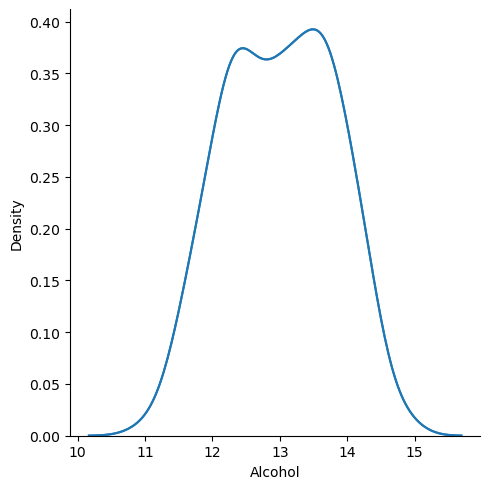

In [ ]:
sns.displot(data=df, x='Alcohol', kind='kde')
#sns.kdeplot(data=df, x='Alcohol')

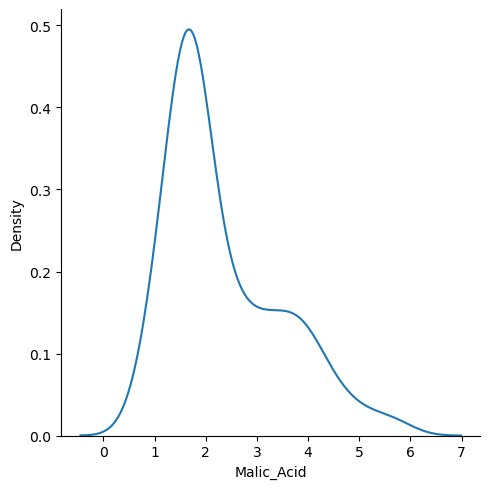

In [11]:
sns.displot(data=df, x='Malic_Acid', kind='kde')

<Axes: xlabel='Alcohol', ylabel='Malic_Acid'>

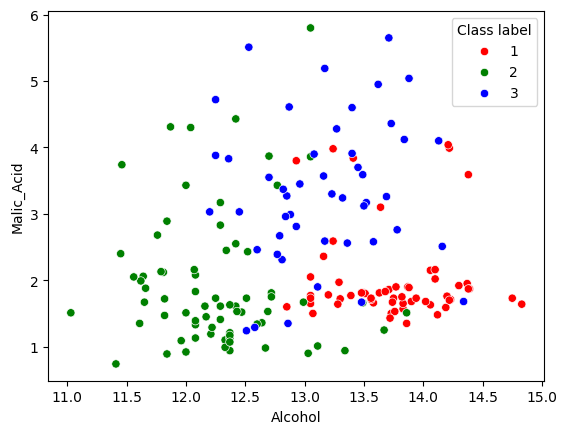

In [12]:
color_dist={1: 'red', 2: 'green', 3: 'blue'}
sns.scatterplot(data=df, x='Alcohol', y='Malic_Acid', hue='Class label', palette=color_dist)

In [14]:
# whenever we are doing any type of scaling, we should do train test split first
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['Alcohol', 'Malic_Acid']], df['Class label'], test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [15]:
#fit on training data and transform both training and testing data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#fit the scaler on the training data, it will learn the parameter
scaler.fit(X_train)

#transform on test and train data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [17]:
np.round(X_train.describe(),1)

,Alcohol,Malic_Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [ ]:
# we look for min and max here
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic_Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


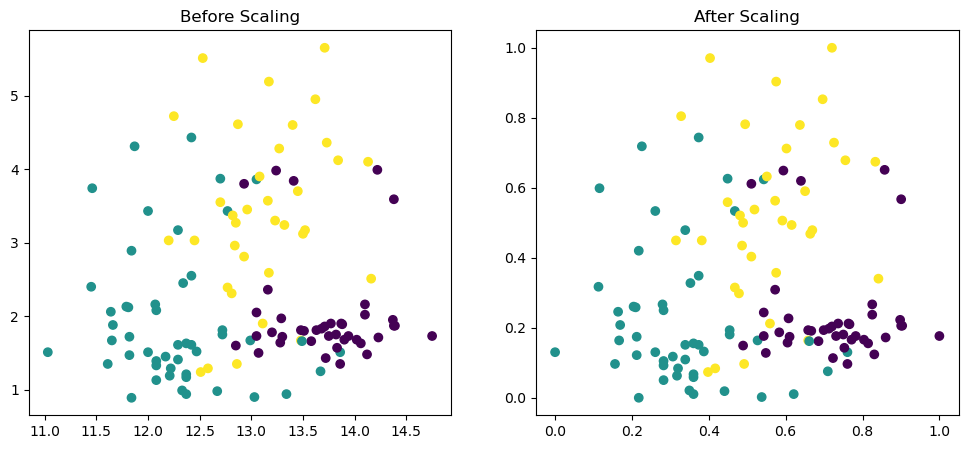

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic_Acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic_Acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

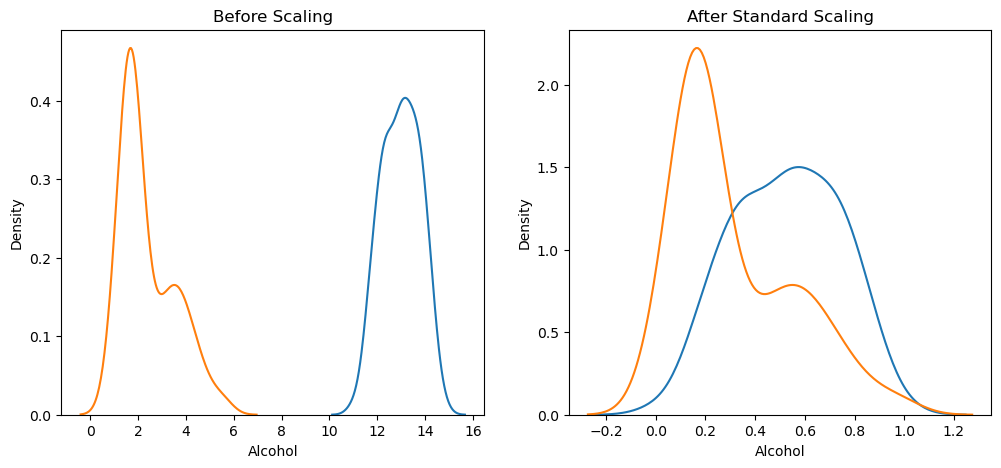

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic_Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic_Acid'], ax=ax2)
plt.show()

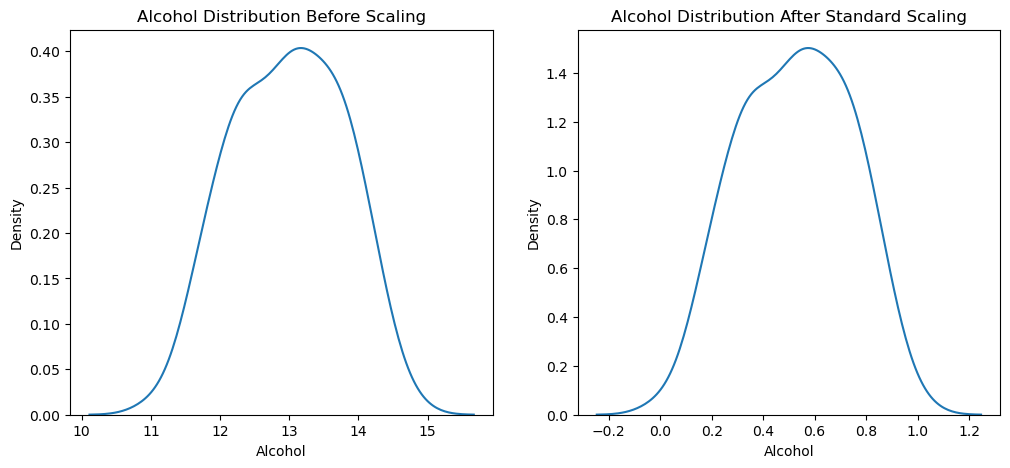

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

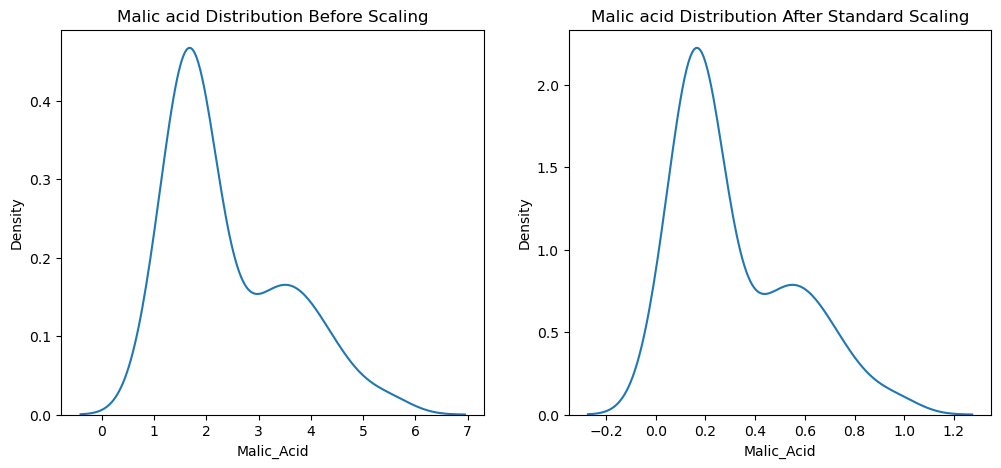

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic_Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic_Acid'], ax=ax2)
plt.show()